# Task-evoked activation and dyslexia: nested cross-validated classification with feature selection

Companion notebook to the written report. Section numbers match the report.

**What runs here and what is loaded.** Every model in the report was fitted by `code/ml_23_feature_selection.py`
(launched by `code/run_ml_v5.sh`), which writes one results file per task and analysis arm to `ml/results_v5/`.
The permutation tests alone take about a day of computation, so this notebook does not refit them. It
(1) imports the same pipeline code and shows exactly how every model is built,
(2) re-runs one complete configuration live and checks that it reproduces the stored result,
(3) computes the cheap analyses live (sample description, confounds, error analysis), and
(4) loads the stored results for every other table and figure.

Participant identifiers are never displayed; individual-level outputs use anonymous indices.

In [1]:
import os, sys, json, importlib.util, warnings
warnings.filterwarnings("ignore")
os.environ["DYSCO_ML_VERSION"] = "v5"          # features from the v5 first level (see report §2.1)

ROOT = "/DATA_CNS/PROJECTS/DYSCOBRAIN/Database/derivatives/task-fmri"
REPORT = os.path.join(ROOT, "reports", "ml_report_v5")
RES = os.path.join(ROOT, "ml", "results_v5")
sys.path.insert(0, os.path.join(ROOT, "code"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy import stats
import sklearn
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score

spec = importlib.util.spec_from_file_location("ml23", os.path.join(ROOT, "code", "ml_23_feature_selection.py"))
ml23 = importlib.util.module_from_spec(spec); spec.loader.exec_module(ml23)
spec = importlib.util.spec_from_file_location("figs", os.path.join(REPORT, "make_result_figures.py"))
figs = importlib.util.module_from_spec(spec); spec.loader.exec_module(figs)

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
print("Python", sys.version.split()[0], "| scikit-learn", sklearn.__version__, "| numpy", np.__version__,
      "| pandas", pd.__version__, "| features version:", ml23.VERSION)

Python 3.12.2 | scikit-learn 1.7.2 | numpy 1.26.4 | pandas 2.3.3 | features version: v5


## 2.1 Participants and data

Each task is its own dataset: every participant with usable data for that task contributes to it. Three participants
were excluded before modelling because their anatomical image could not be verified as their own.

In [2]:
DATA = {}
for task in ["gait", "articulation"]:
    X, y, conf, feat, subjects = ml23.load(task)
    DATA[task] = dict(X=X, y=y, conf=conf, feat=feat, subjects=subjects)
    print(f"{task:13s} N = {len(y)}  (DYS {y.sum()}, TYP {(1 - y).sum()})   features = {X.shape[1]}   "
          f"missing cells = {np.isnan(X).mean():.1%}   confounds = {ml23.CONFOUNDS}")

gait          N = 36  (DYS 16, TYP 20)   features = 97   missing cells = 3.8%   confounds = ['age', 'motion_n_outliers', 'n_usable_runs']
articulation  N = 32  (DYS 17, TYP 15)   features = 97   missing cells = 3.6%   confounds = ['age', 'motion_n_outliers', 'n_usable_runs']


## 2.2 Feature construction

97 regional means per participant and task: 48 cortical and 15 subcortical regions (Harvard-Oxford) and 34 cerebellar
regions (Diedrichsen atlas). Values covering less than 50% of their region are missing and are imputed with the
training-fold median inside the pipeline.

In [3]:
feat = pd.Series(DATA["gait"]["feat"])
atlas = np.where(feat.str.startswith("SUIT_"), "Cerebellum (Diedrichsen)",
         np.where(feat.isin([f for f in feat if any(s in f for s in ["Thalamus", "Caudate", "Putamen", "Pallidum",
                  "Hippocampus", "Amygdala", "Accumbens", "Brain-Stem"])]), "Subcortical (Harvard-Oxford)", "Cortical (Harvard-Oxford)"))
print(pd.Series(atlas).value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, task in zip(axes, DATA):
    miss = pd.Series(np.isnan(DATA[task]["X"]).mean(0), index=[f.replace("HO_", "").replace("SUIT_", "") for f in DATA[task]["feat"]])
    miss[miss > 0].sort_values(ascending=False).head(10)[::-1].plot.barh(ax=ax, color="#041B39")
    ax.set_title(f"{task}: regions with most missing values"); ax.set_xlabel("fraction of participants missing")
plt.tight_layout(); plt.show()

Cortical (Harvard-Oxford)       48
Cerebellum (Diedrichsen)        34
Subcortical (Harvard-Oxford)    15


## 2.3 Pipeline and leakage control

Every data-fitted step is a step of one scikit-learn `Pipeline`, so `GridSearchCV` refits all of them on each
training fold. The confound-controlled variant appends the confounds as the last columns; the residualiser regresses
them out using coefficients estimated on the training fold only.

Pipeline(steps=[('impute',
                 SimpleImputer(keep_empty_features=True, strategy='median')),
                ('resid', ConfoundResidualizer(n_confounds=3)),
                ('scale', StandardScaler()),
                ('sel',
                 SequentialFeatureSelector(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
                                           estimator=LogisticRegression(max_iter=2000,
                                                                        solver='liblinear'),
                                           n_features_to_select=10, n_jobs=1,
                                           scoring='balanced_accuracy')),
                ('clf', LogisticRegression(max_iter=2000, solver='liblinear'))])


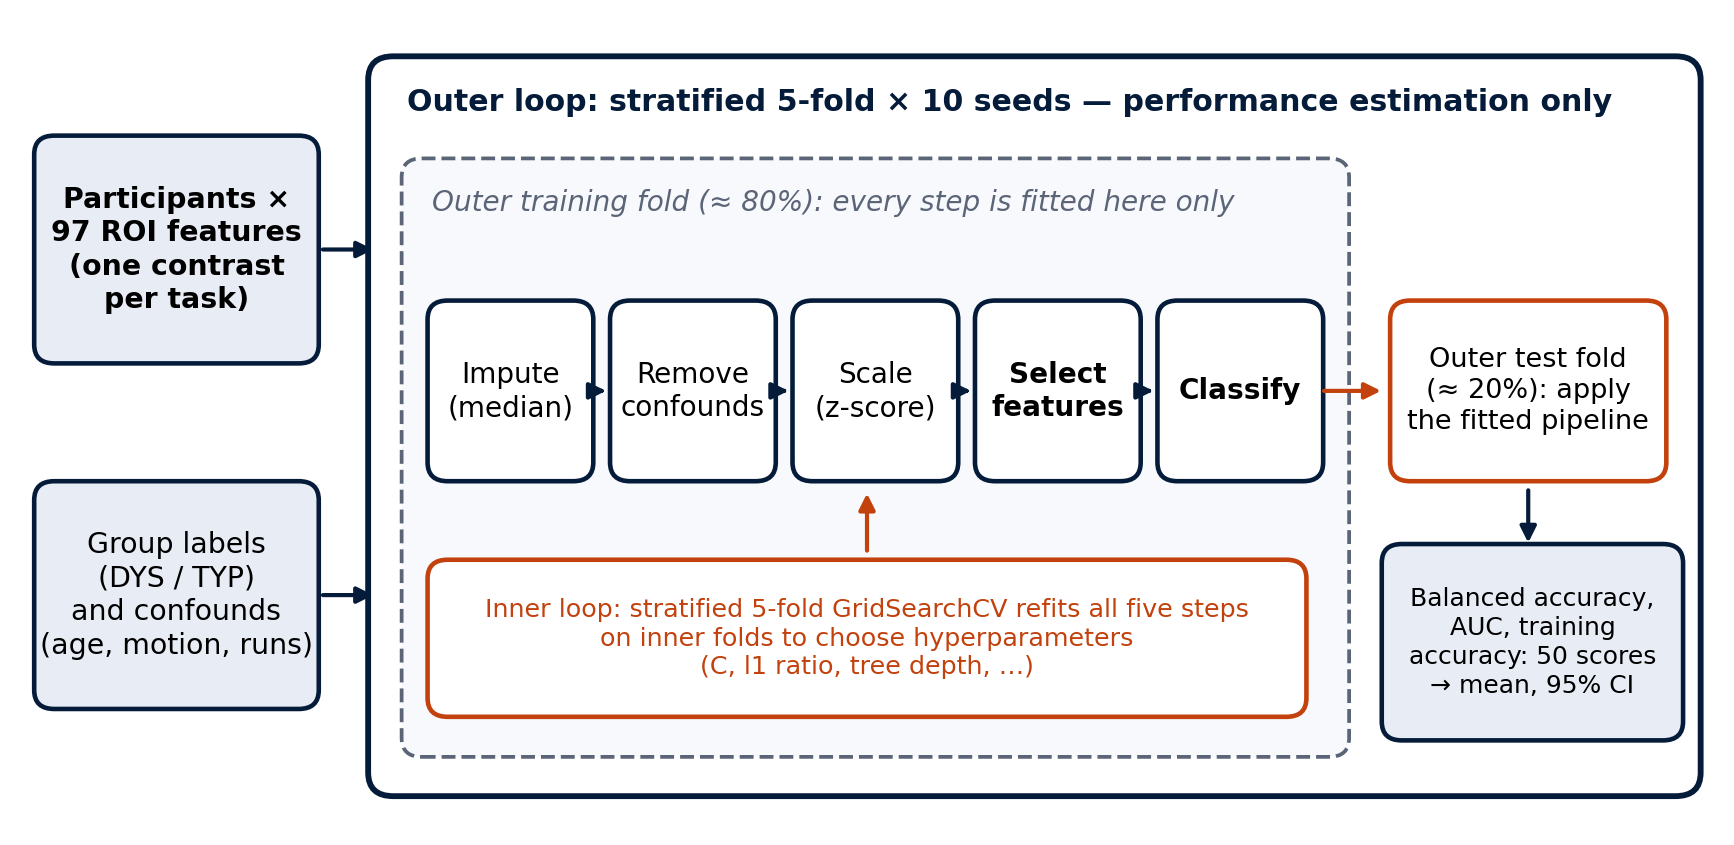

In [4]:
example = ml23.build("l2_logistic", "controlled", n_conf=3,
                     selector=ml23.make_selector("sfs", 10, "l2_logistic", 1.0, seed=0))
print(example)
display(Image(os.path.join(REPORT, "fig1_pipeline.png"), width=850))

## 2.4 – 2.5 Feature selection, models and hyperparameter grids

Selectors: filter (`SelectKBest`, ANOVA F), recursive feature elimination (`RFE`, L2 logistic coefficients) and forward
sequential feature selection (`SequentialFeatureSelector`, balanced accuracy in its own 5-fold CV). Grids are coarse and
were fixed before any result was seen.

In [5]:
ROLE = {"l2_logistic": "primary", "linear_svm": "primary", "elasticnet_logistic": "secondary (sparse)",
        "random_forest": "exploratory", "decision_tree": "complexity ladder", "gradient_boosting": "complexity ladder"}
pd.DataFrame([{"model": k, "role": ROLE[k], "estimator": type(v["estimator"]).__name__,
               "grid": "; ".join(f"{p.replace('clf__', '')} ∈ {vals}" for p, vals in v["grid"].items())}
              for k, v in ml23.MODELS.items()])

,model,role,estimator,grid
0,l2_logistic,primary,LogisticRegression,"C ∈ [0.001, 0.01, 0.1, 1, 10]"
1,linear_svm,primary,SVC,"C ∈ [0.001, 0.01, 0.1, 1, 10]"
2,elasticnet_logistic,secondary (sparse),LogisticRegression,"C ∈ [0.001, 0.01, 0.1, 1, 10]; l1_ratio ∈ [0.1..."
3,random_forest,exploratory,RandomForestClassifier,"max_depth ∈ [None, 5, 10]"
4,decision_tree,complexity ladder,DecisionTreeClassifier,"max_depth ∈ [2, 3, 5, None]; min_samples_leaf ..."
5,gradient_boosting,complexity ladder,GradientBoostingClassifier,"max_depth ∈ [2, 3]; learning_rate ∈ [0.01, 0.1..."


## 2.6 Validation: one configuration re-run live

Nested cross-validation: outer stratified 5-fold × 10 seeds (50 test folds), inner stratified 5-fold grid search.
The cell below re-runs the all-feature L2 logistic model on articulation (raw variant) with exactly the code and seeds
used for the report, and compares it with the stored result.

In [6]:
d = DATA["articulation"]
folds = [f for s in range(10) for f in ml23.one_seed(d["X"], d["y"], d["conf"], "raw", "l2_logistic", s, feat_names=d["feat"])]
live = ml23.summarise(folds)
stored = json.load(open(os.path.join(RES, "articulation_baseline.json")))["results"]["baseline__l2_logistic__raw"]
for name, r in [("live", live), ("stored", stored)]:
    b = r["balanced_accuracy"]
    print(f"{name:6s}: balanced accuracy {b['mean']:.3f} [95% {b['ci95_lo']:.2f}, {b['ci95_hi']:.2f}]   "
          f"AUC {r['roc_auc']['mean']:.3f}   train {r['train_balanced_accuracy']['mean']:.3f}")

live  : balanced accuracy 0.757 [95% 0.50, 1.00]   AUC 0.806   train 0.993
stored: balanced accuracy 0.757 [95% 0.50, 1.00]   AUC 0.806   train 0.993


## 3.1 Sample, features and confounds

Each candidate confound is tested for a group difference and for its ability to classify group on its own,
with the same nested procedure (logistic regression, C chosen by inner CV, 10 × 5-fold).

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

neuro = pd.read_csv(json.load(open(os.path.join(ROOT, "config", "config.json")))["paths"]["neuropsy_csv"]).set_index("subject")
rows = []
for task, d in DATA.items():
    y = d["y"]
    covs = {"age": d["conf"][:, 0], "motion-outlier volumes": d["conf"][:, 1], "usable runs": d["conf"][:, 2],
            "sex (female)": (neuro.loc[d["subjects"], "sex"] == "F").to_numpy(float)}
    for name, x in covs.items():
        p = stats.fisher_exact(pd.crosstab(y, x).values)[1] if name.startswith("sex") else stats.mannwhitneyu(x[y == 1], x[y == 0]).pvalue
        ba = []
        for s in range(10):
            for tr, te in StratifiedKFold(5, shuffle=True, random_state=s).split(x.reshape(-1, 1), y):
                m = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
                                 {"logisticregression__C": [.01, .1, 1, 10]}, cv=StratifiedKFold(5, shuffle=True, random_state=s),
                                 scoring="balanced_accuracy").fit(x.reshape(-1, 1)[tr], y[tr])
                ba.append(balanced_accuracy_score(y[te], m.predict(x.reshape(-1, 1)[te])))
        rows.append({"task": task, "confound": name,
                     "DYS": np.mean(x[y == 1]) if name.startswith("sex") else np.median(x[y == 1]),
                     "TYP": np.mean(x[y == 0]) if name.startswith("sex") else np.median(x[y == 0]),
                     "p (group difference)": p, "balanced accuracy alone": np.mean(ba),
                     "95% CI": f"[{np.percentile(ba, 2.5):.2f}, {np.percentile(ba, 97.5):.2f}]"})
pd.DataFrame(rows).round(3)

,task,confound,DYS,TYP,p (group difference),balanced accuracy alone,95% CI
0,gait,age,21.000,24.00,0.007,0.685,"[0.26, 1.00]"
1,gait,motion-outlier volumes,18.000,9.00,0.238,0.502,"[0.38, 0.67]"
2,gait,usable runs,2.000,2.00,0.019,0.600,"[0.50, 0.75]"
3,gait,sex (female),0.875,0.75,0.426,0.482,"[0.33, 0.50]"
4,articulation,age,21.000,23.00,0.170,0.520,"[0.33, 0.71]"
5,articulation,motion-outlier volumes,33.000,17.00,0.079,0.559,"[0.19, 0.83]"
6,articulation,usable runs,2.000,2.00,1.000,0.500,"[0.50, 0.50]"
7,articulation,sex (female),0.882,0.80,0.645,0.475,"[0.33, 0.50]"


## 3.2 – 3.4 Classification, overfitting and feature selection

All configurations, from the stored results. `p_perm` is the label-permutation p-value (500 permutations for the two
pre-specified headline configurations, 200 otherwise); configurations without one were reported descriptively.
A configuration is positive only if `p_perm < .05` **and** the 95% interval excludes 0.5.

In [8]:
T = figs.table()
T["positive"] = (T.p_perm < .05) & (T.ci_lo > .5)
show = T[T.arm.isin(["baseline", "sfs", "kbest", "ladder"])][["task", "arm", "config", "bal_acc", "ci_lo", "ci_hi", "auc",
                                                             "train_bal_acc", "gap", "p_perm", "n_perm", "positive"]]
show.round(3)

,task,arm,config,bal_acc,ci_lo,ci_hi,auc,train_bal_acc,gap,p_perm,n_perm,positive
0,gait,baseline,baseline__l2_logistic__raw,0.556,0.250,0.866,0.614,0.857,0.301,0.269,200.0,False
1,gait,baseline,baseline__l2_logistic__controlled,0.542,0.292,0.866,0.480,0.953,0.411,0.343,200.0,False
2,gait,baseline,baseline__linear_svm__raw,0.513,0.250,0.750,0.595,0.893,0.380,0.313,200.0,False
3,gait,baseline,baseline__linear_svm__controlled,0.536,0.259,0.815,0.517,0.858,0.322,0.244,200.0,False
4,gait,baseline,baseline__elasticnet_logistic__raw,0.512,0.153,0.750,0.618,0.907,0.394,0.323,200.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
89,articulation,ladder,ladder__decision_tree__kbest10__controlled,0.529,0.134,0.875,0.531,0.895,0.366,0.393,200.0,False
90,articulation,ladder,ladder__gradient_boosting__kbest5__raw,0.587,0.292,0.972,0.619,0.956,0.370,0.209,200.0,False
91,articulation,ladder,ladder__gradient_boosting__kbest5__controlled,0.601,0.269,0.972,0.625,0.960,0.359,0.164,200.0,False
92,articulation,ladder,ladder__gradient_boosting__kbest10__raw,0.562,0.292,0.866,0.586,0.968,0.405,0.249,200.0,False


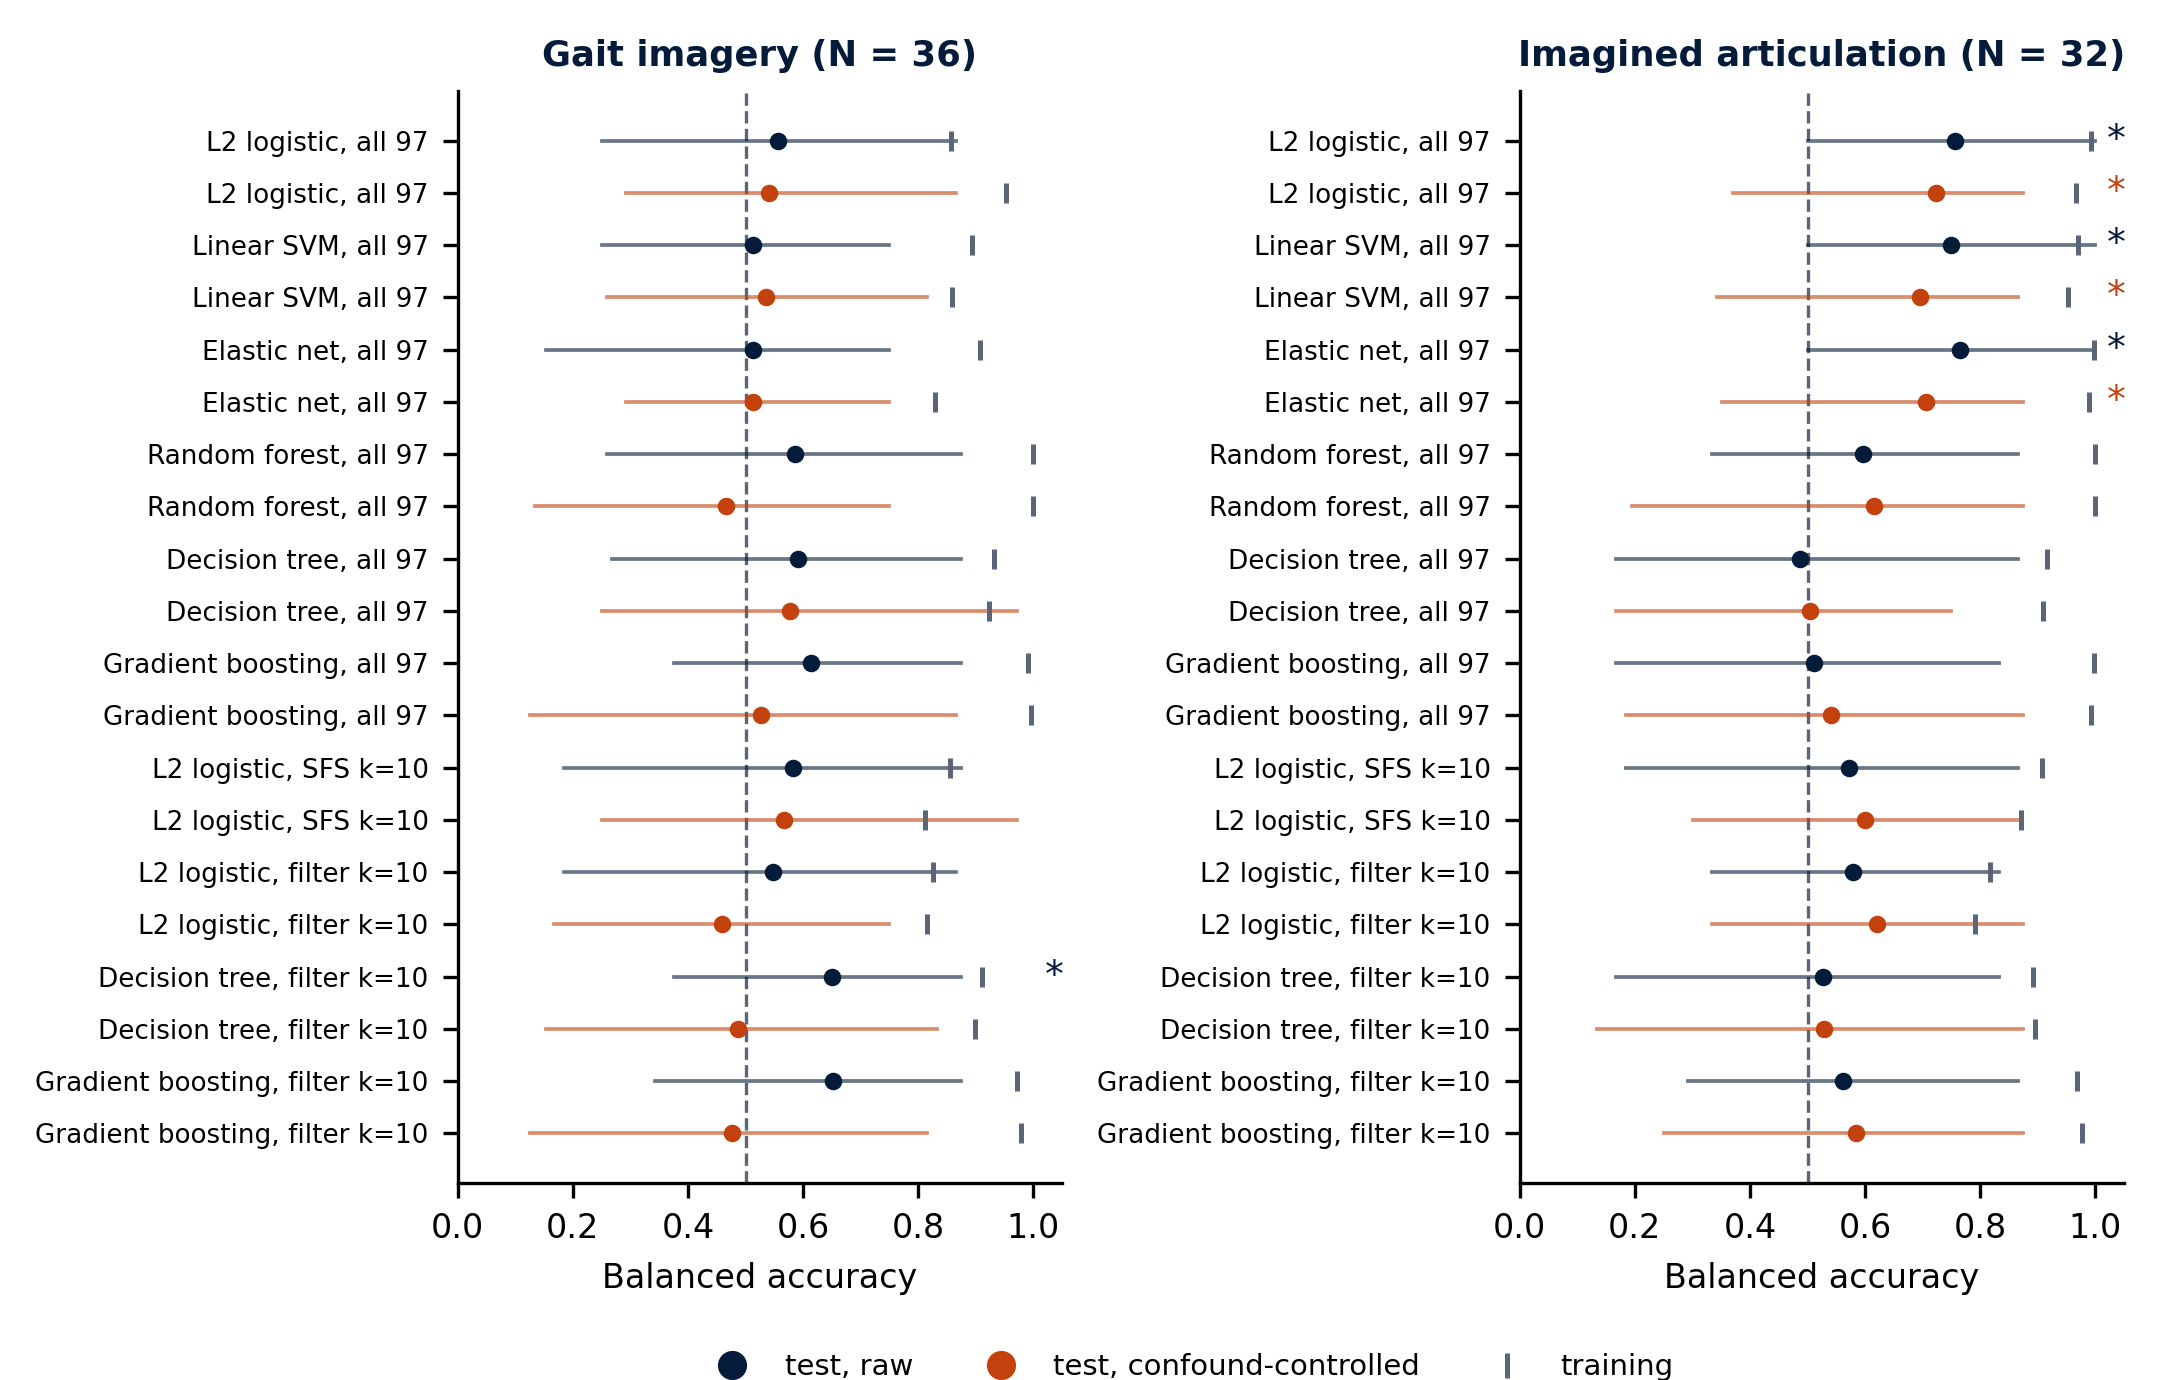

In [9]:
figs.fig_performance(T)
display(Image(os.path.join(REPORT, "fig2_performance.png"), width=900))

In [10]:
# Train-test gap by model family (mean over configurations): a descriptive index of overfitting (report §3.3)
g = T[T.arm.isin(["baseline", "sfs", "kbest", "ladder"])].copy()
g["model"] = g.config.str.split("__").str[1]
g.groupby(["task", "model"])[["train_bal_acc", "bal_acc", "gap"]].mean().round(2)

train_bal_acc  bal_acc   gap
task         model                                            
articulation decision_tree                 0.90     0.51  0.38
             elasticnet_logistic           0.99     0.74  0.26
             gradient_boosting             0.98     0.56  0.41
             l2_logistic                   0.86     0.62  0.24
             linear_svm                    0.90     0.63  0.27
             random_forest                 1.00     0.61  0.39
gait         decision_tree                 0.91     0.57  0.34
             elasticnet_logistic           0.87     0.51  0.36
             gradient_boosting             0.98     0.56  0.42
             l2_logistic                   0.83     0.54  0.29
             linear_svm                    0.84     0.55  0.29
             random_forest                 1.00     0.53  0.47

## 3.3 (continued) Is the 97-feature model overfitted? (report Figure 3)

With 25–29 training participants and 97 features, the training data are linearly separable for almost any labelling, so
training accuracy near 1 says nothing about signal. Every curve below is computed for the all-feature L2 logistic model on
the real labels **and on shuffled labels** (a new permutation per repeat; repeated stratified 5-fold, 10 repeats), raw and
confound-controlled, with the ml_23 pipelines (`code/ml_25_fit_diagnostics_all97.py`): validation curve over C, learning
curve with C re-tuned, correlation of coefficient vectors between the training folds of a repeat, and the C chosen by the
inner CV of the nested analysis. Descriptive only.

In [11]:
spec = importlib.util.spec_from_file_location("ml25", os.path.join(ROOT, "code", "ml_25_fit_diagnostics_all97.py"))
ml25 = importlib.util.module_from_spec(spec); spec.loader.exec_module(ml25)
a97 = {"validation_curve": [], "learning_curve": [], "weight_stability": [], "selected_C": []}
for task, d in DATA.items():
    a97["selected_C"] += ml25.selected_C(task)
    for variant in ("raw", "controlled"):
        C = ml23.modal_C(task, variant)
        for labels in ("real", "shuffled"):
            a97["validation_curve"] += ml25.validation_curve(task, d["X"], d["y"], d["conf"], variant, labels, 8)
            a97["learning_curve"] += ml25.learning_curve(task, d["X"], d["y"], d["conf"], variant, labels, 8)
            a97["weight_stability"].append(ml25.weight_stability(task, d["X"], d["y"], d["conf"], variant, labels, C))
for name, rows in a97.items():
    pd.DataFrame(rows).to_csv(os.path.join(ml25.OUT, f"all97_{name}.csv"), index=False)
v = pd.DataFrame(a97["validation_curve"]).groupby(["task", "variant", "labels", "C"])[["train_bal_acc", "val_bal_acc", "val_logloss"]].mean()
print("Validation curve at selected C values (mean over 50 splits):")
print(v[v.index.get_level_values("C").isin(ml25.C_RANGE[[0, 6, 8, 10, 12]])].round(3).to_string())
print()
lc = pd.DataFrame(a97["learning_curve"]).groupby(["task", "variant", "labels", "frac"])[["n_train", "train_bal_acc", "val_bal_acc"]].mean()
print("Learning curve, smallest and full training set:")
print(lc[lc.index.get_level_values("frac").isin([0.3, 1.0])].round(3).to_string())
print()
print(pd.DataFrame(a97["weight_stability"]).round(3).to_string(index=False))

Validation curve at selected C values (mean over 50 splits):
                                           train_bal_acc  val_bal_acc  val_logloss
task         variant    labels   C                                                
articulation controlled real     0.0001            0.643        0.567        0.690
                                 0.1000            0.956        0.731        0.554
                                 1.0000            0.999        0.722        0.666
                                 10.0000           1.000        0.704        1.079
                                 100.0000          1.000        0.706        1.605
                        shuffled 0.0001            0.705        0.473        0.693
                                 0.1000            0.964        0.522        0.815
                                 1.0000            1.000        0.512        1.289
                                 10.0000           1.000        0.510        2.108
                          

saved


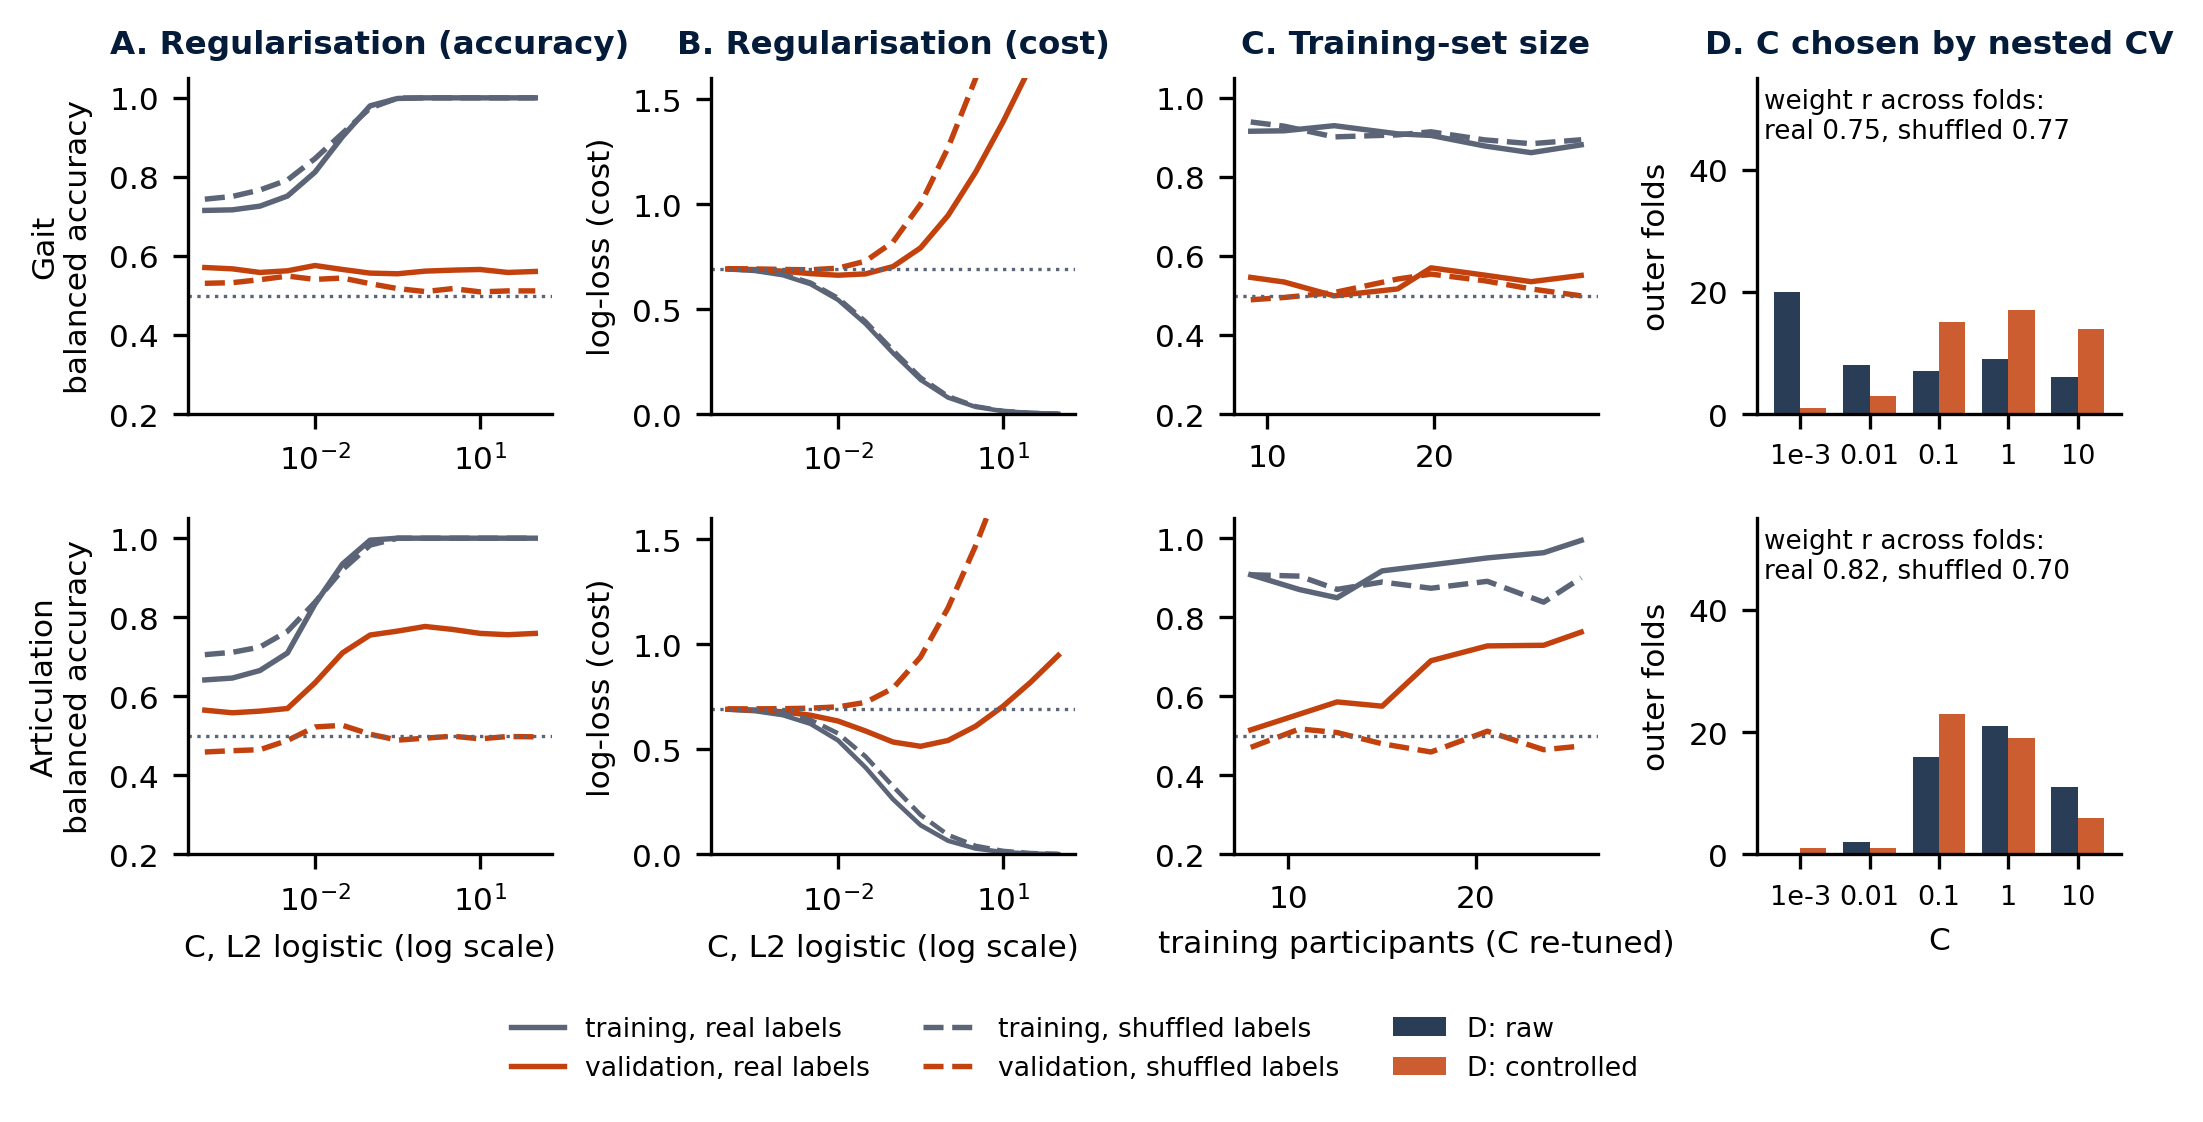

In [12]:
exec(open(os.path.join(REPORT, "make_fit_figure_all97.py")).read(), {"__file__": os.path.join(REPORT, "make_fit_figure_all97.py")})
display(Image(os.path.join(REPORT, "fig6_fit_all97.png"), width=950))

## 3.3 (continued) Supplementary diagnostics on the 10 best features (notebook only)

Computed live on the reduced feature set (10 best features by ANOVA F, selected inside each training fold; repeated
stratified 5-fold, 10 repeats). (A) training and validation log-loss (the cost minimised by logistic regression) across
the L2 penalty; (B) learning curve with C re-tuned at every training-set size; (C) training and validation log-loss
across gradient-boosting iterations; (D) accuracy across decision-tree depth. Descriptive only: no configuration in the
report was chosen from these curves.

In [13]:
spec = importlib.util.spec_from_file_location("ml24", os.path.join(ROOT, "code", "ml_24_fit_diagnostics.py"))
ml24 = importlib.util.module_from_spec(spec); spec.loader.exec_module(ml24)
diag = {"validation_curve": [], "learning_curve": [], "boosting_curve": [], "tree_curve": []}
for task, d in DATA.items():
    diag["validation_curve"] += ml24.validation_curve(task, d["X"], d["y"], 4)
    diag["learning_curve"] += ml24.learning_curve(task, d["X"], d["y"], 4)
    diag["boosting_curve"] += ml24.boosting_curve(task, d["X"], d["y"], 4)
    diag["tree_curve"] += ml24.tree_curve(task, d["X"], d["y"], 4)
os.makedirs(ml24.OUT, exist_ok=True)
for name, rows in diag.items():
    pd.DataFrame(rows).to_csv(os.path.join(ml24.OUT, f"{name}.csv"), index=False)
v = pd.DataFrame(diag["validation_curve"]).groupby(["task", "features", "C"])[["train_logloss", "val_logloss", "val_bal_acc"]].mean()
best = v.groupby(level=[0, 1]).val_logloss.idxmin()
print("Minimum validation log-loss per task and feature set:")
print(v.loc[best].round(3).to_string())
b = pd.DataFrame(diag["boosting_curve"])
print()
print("Gradient boosting, iteration with the lowest validation log-loss:")
print(b.loc[b.groupby("task").val_logloss.idxmin(), ["task", "iteration", "train_logloss", "val_logloss"]].round(3).to_string(index=False))

/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warni

/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warni

/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warni

/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warni

/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79 81] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [76 79] are constant.
 

...

/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warni

/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [79] are constant.
  warni

/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warni

/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/gcannavacciuolo/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warni

Minimum validation log-loss per task and feature set:
                                train_logloss  val_logloss  val_bal_acc
task         features C                                                
articulation 10 best  0.031623          0.548        0.637        0.610
             all 97   0.316228          0.139        0.503        0.769
gait         10 best  0.031623          0.532        0.660        0.593
             all 97   0.010000          0.539        0.656        0.606

Gradient boosting, iteration with the lowest validation log-loss:
        task  iteration  train_logloss  val_logloss
articulation          2          0.588        0.692
        gait          5          0.412        0.637


saved


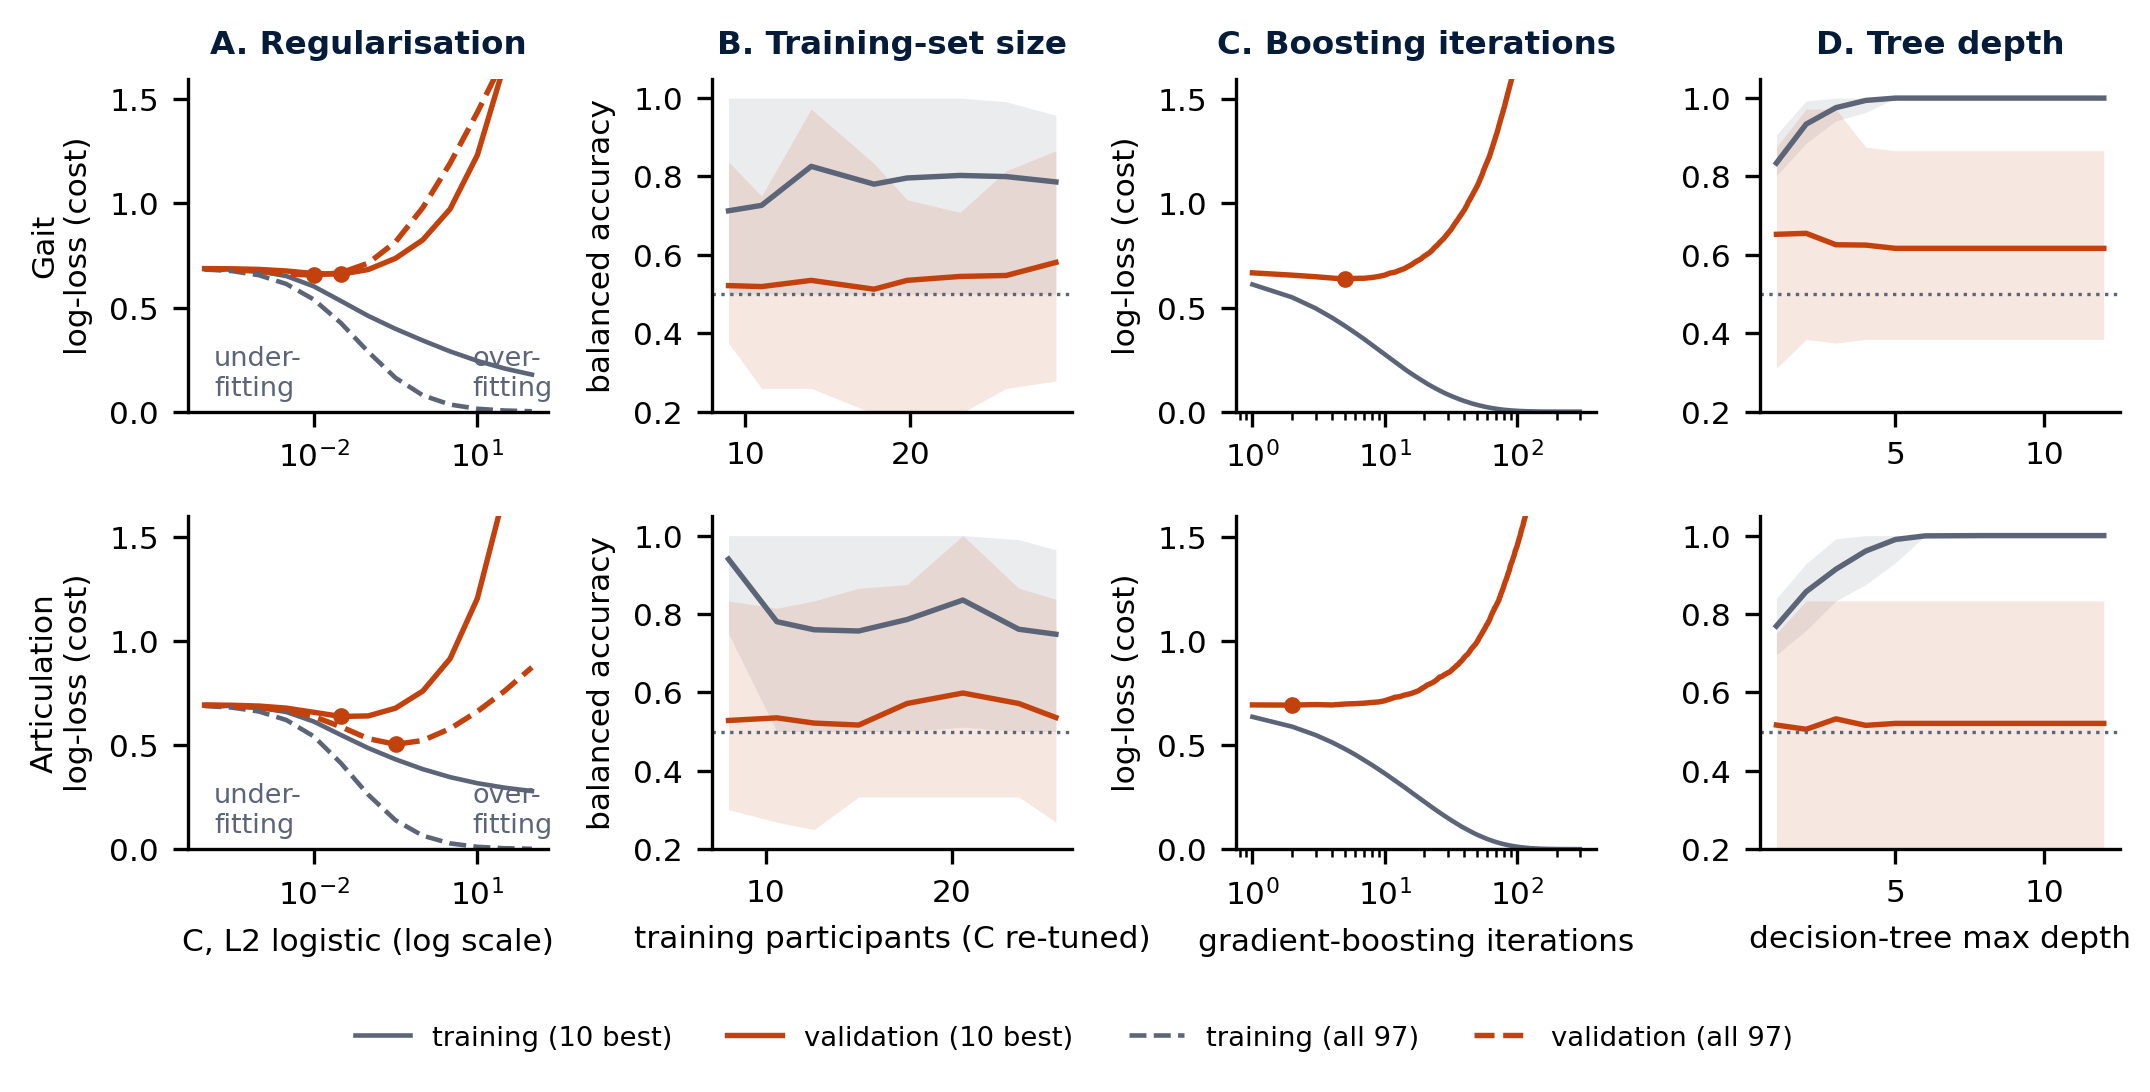

In [14]:
exec(open(os.path.join(REPORT, "make_fit_figure.py")).read(), {"__file__": os.path.join(REPORT, "make_fit_figure.py")})
display(Image(os.path.join(REPORT, "fig5_fit_diagnostics.png"), width=950))

## 3.4 Feature-count curve (RFE)

Predictions written before the curve was computed: under the dilution hypothesis, balanced accuracy peaks at small k;
under a distributed or absent signal, it is flat or declines as k decreases. A peak in the point estimates whose
interval still includes 0.5 is not evidence of an effect.

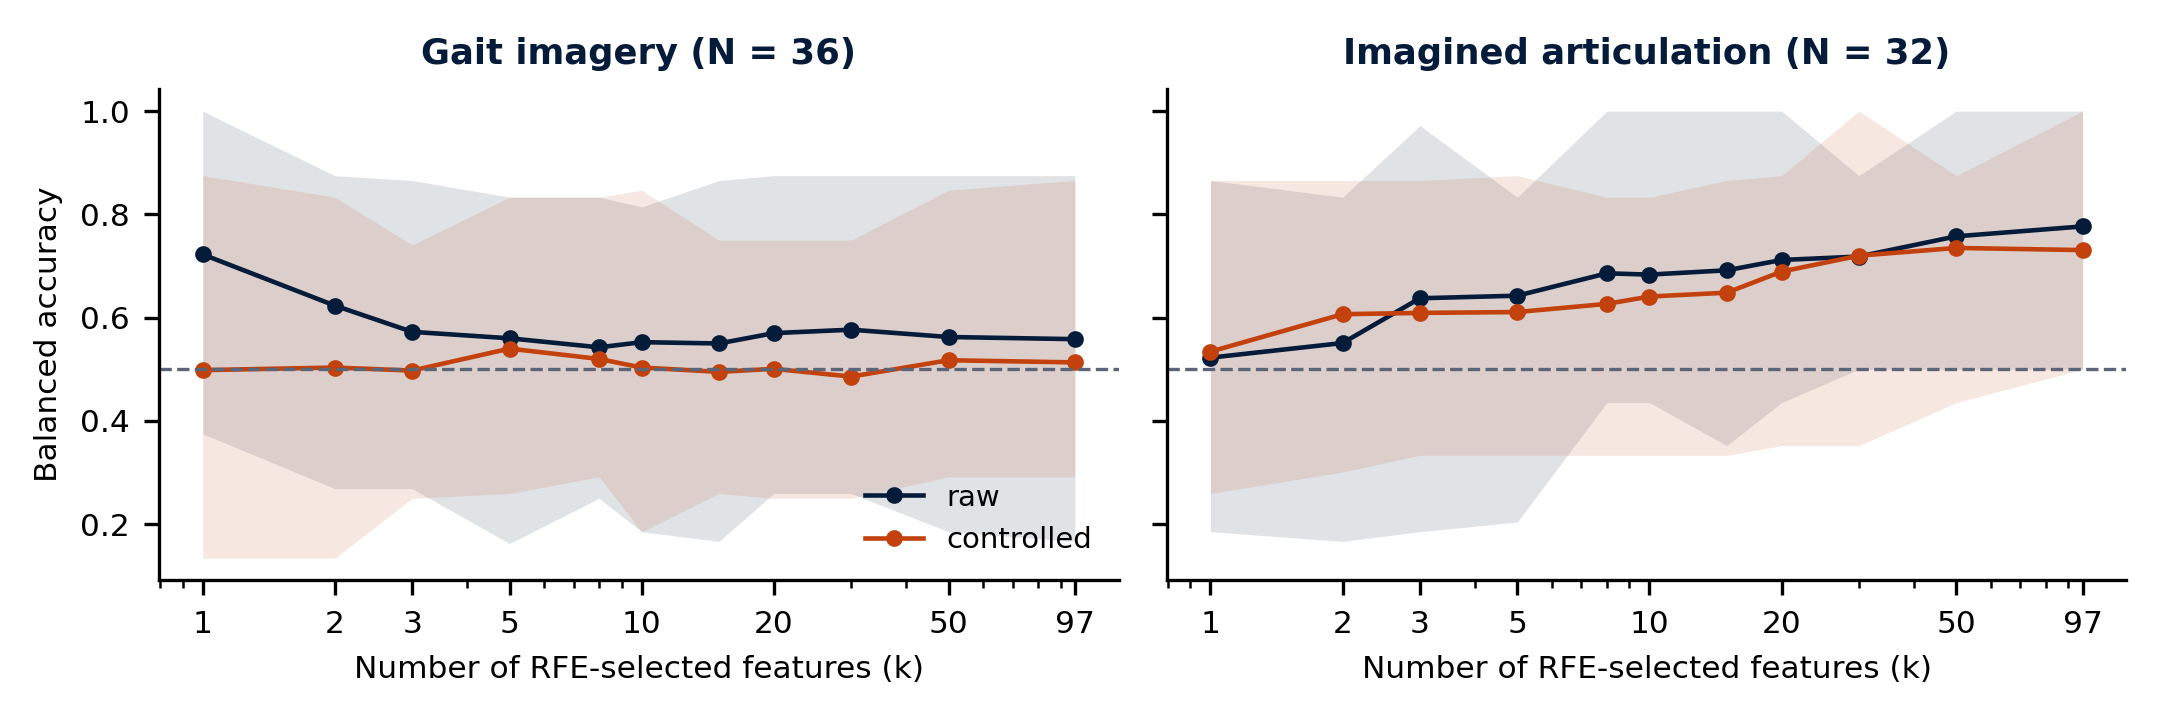

,task,config,bal_acc,ci_lo,ci_hi,p_perm
32,gait,rfe__l2_logistic__k1__raw,0.722,0.375,1.000,0.025
33,gait,rfe__l2_logistic__k2__raw,0.623,0.269,0.875,0.139
34,gait,rfe__l2_logistic__k3__raw,0.572,0.269,0.866,0.289
35,gait,rfe__l2_logistic__k5__raw,0.560,0.162,0.833,0.284
36,gait,rfe__l2_logistic__k8__raw,0.542,0.250,0.833,0.368
37,gait,rfe__l2_logistic__k10__raw,0.552,0.185,0.815,0.333
38,gait,rfe__l2_logistic__k15__raw,0.550,0.167,0.866,0.333
39,gait,rfe__l2_logistic__k20__raw,0.570,0.259,0.875,0.284
40,gait,rfe__l2_logistic__k30__raw,0.577,0.259,0.875,0.224
41,gait,rfe__l2_logistic__k50__raw,0.562,0.185,0.875,0.239


In [15]:
figs.fig_rfe(T)
p = os.path.join(REPORT, "fig3_rfe_curve.png")
display(Image(p, width=900)) if os.path.exists(p) else print("RFE curve not computed yet")
T[T.arm == "rfe_curve"][["task", "config", "bal_acc", "ci_lo", "ci_hi", "p_perm"]].round(3)

## 3.5 Selection stability

How often each region is selected across the 50 outer training folds. Regions selected in only a minority of folds
indicate a noise-driven ranking and are not interpreted anatomically.

In [16]:
rows = []
for task in DATA:
    for arm in ["sfs", "kbest"]:
        for cfg, r in figs.load_arm(task, arm).items():
            if r.get("selection_frequency"):
                top = sorted(r["selection_frequency"].items(), key=lambda kv: -kv[1])[:3]
                rows.append({"task": task, "config": cfg, **{f"top {i+1}": f"{n.replace('HO_', '').replace('SUIT_', '')} ({f:.2f})"
                                                              for i, (n, f) in enumerate(top)}})
pd.DataFrame(rows)

,task,config,top 1,top 2,top 3
0,gait,sfs__l2_logistic__k5__raw,"Middle Temporal Gyrus, anterior division (0.72)",Frontal Pole (0.28),Left Thalamus (0.24)
1,gait,sfs__l2_logistic__k5__controlled,"Middle Temporal Gyrus, anterior division (0.74)",Frontal Pole (0.16),"Inferior Temporal Gyrus, posterior division (0..."
2,gait,sfs__l2_logistic__k10__raw,"Middle Temporal Gyrus, anterior division (0.74)","Inferior Temporal Gyrus, posterior division (0...",Frontal Pole (0.48)
3,gait,sfs__l2_logistic__k10__controlled,"Middle Temporal Gyrus, anterior division (0.74)",Precentral Gyrus (0.32),"Middle Temporal Gyrus, posterior division (0.32)"
4,gait,sfs__linear_svm__k5__raw,"Middle Temporal Gyrus, anterior division (0.76)",Superior Frontal Gyrus (0.34),Frontal Pole (0.22)
5,gait,sfs__linear_svm__k5__controlled,"Middle Temporal Gyrus, anterior division (0.74)",Insular Cortex (0.28),Precentral Gyrus (0.22)
6,gait,sfs__linear_svm__k10__raw,"Middle Temporal Gyrus, anterior division (0.72)",Superior Frontal Gyrus (0.48),Frontal Pole (0.44)
7,gait,sfs__linear_svm__k10__controlled,"Middle Temporal Gyrus, anterior division (0.72)",Temporal Pole (0.46),"Superior Temporal Gyrus, posterior division (0..."
8,gait,kbest__l2_logistic__k5__raw,"Middle Temporal Gyrus, anterior division (1.00)",Angular Gyrus (0.56),Left Hippocampus (0.44)
9,gait,kbest__l2_logistic__k5__controlled,"Middle Temporal Gyrus, anterior division (0.96)",Right_V (0.42),Parietal Opercular Cortex (0.24)


## 3.6 Demonstration: feature selection outside the folds (methodological error, not a result)

Arm A selects features inside each training fold (correct). Arm B selects them once on all participants before
cross-validation (wrong). Both are run on the real features and on pure Gaussian noise of identical shape. Arm B is
tested against the careless null (selection kept fixed) and against a null that repeats the selection on every
permuted label set.

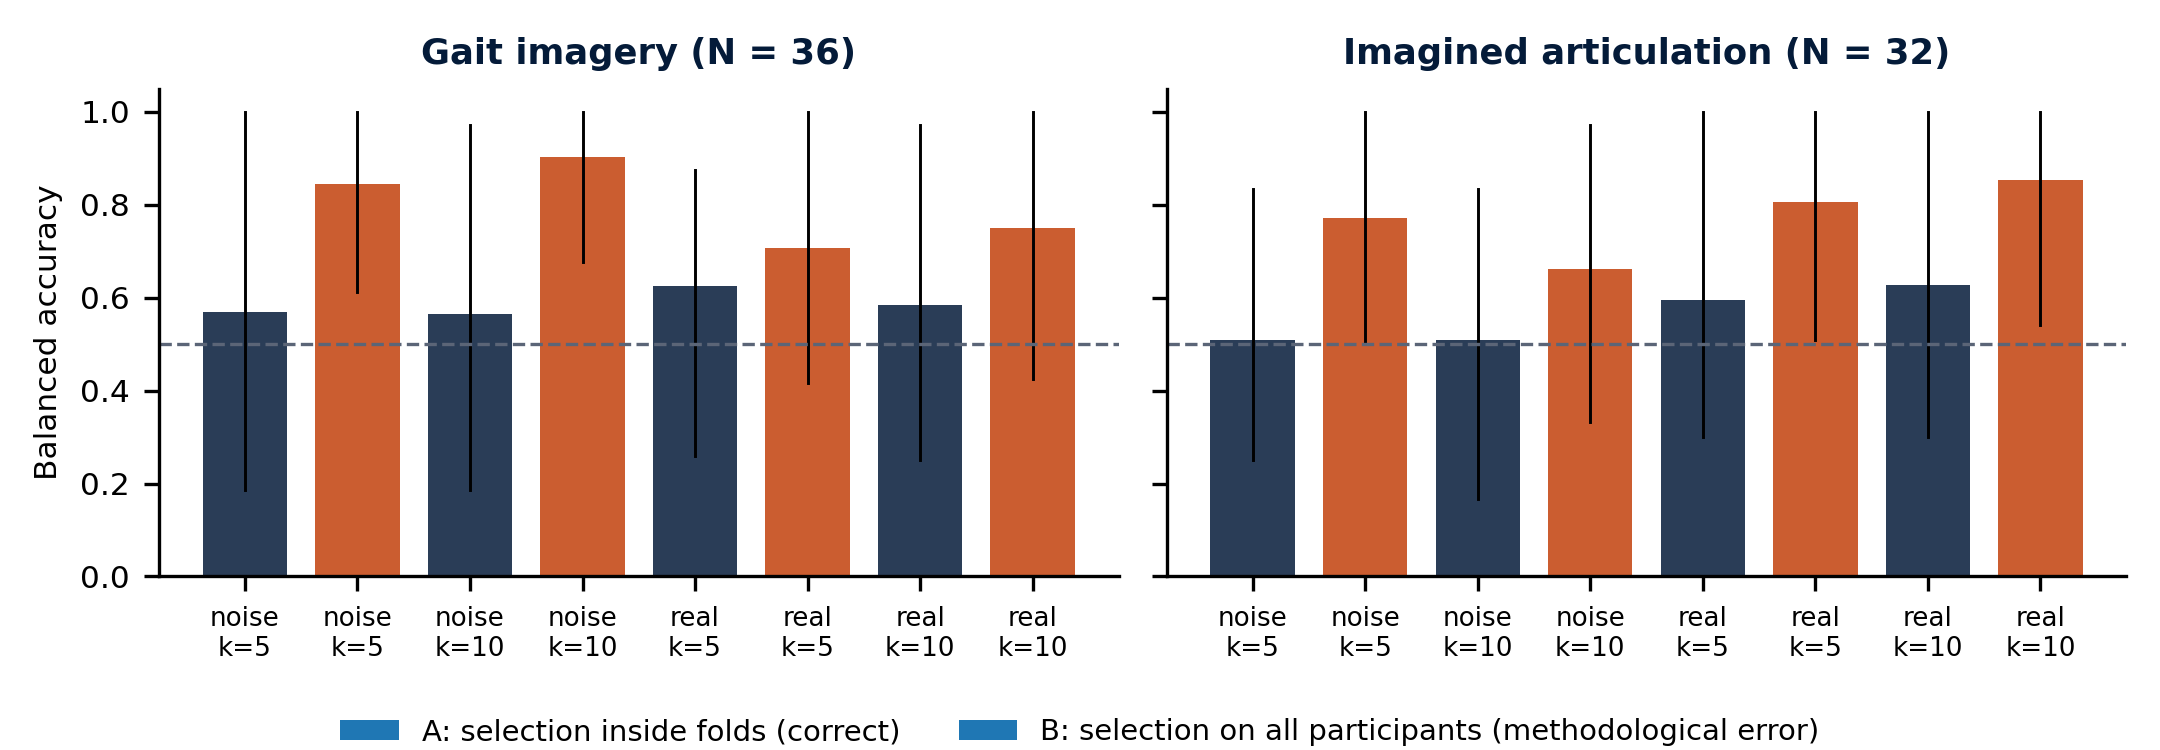

,task,config,bal_acc,ci_lo,ci_hi,p_perm,p_fixed_selection,p_reselect
54,gait,demo__real__armA_correct__k5,0.625,0.259,0.875,0.129,NaN,NaN
55,gait,demo__real__armB_WRONG__k5,0.707,0.417,1.000,NaN,0.020,0.632
56,gait,demo__real__armA_correct__k10,0.585,0.250,0.972,0.224,NaN,NaN
57,gait,demo__real__armB_WRONG__k10,0.750,0.426,1.000,NaN,0.005,0.259
58,gait,demo__noise__armA_correct__k5,0.569,0.185,1.000,NaN,NaN,NaN
59,gait,demo__noise__armB_WRONG__k5,0.845,0.611,1.000,NaN,NaN,NaN
60,gait,demo__noise__armA_correct__k10,0.566,0.185,0.972,NaN,NaN,NaN
61,gait,demo__noise__armB_WRONG__k10,0.902,0.676,1.000,NaN,NaN,NaN
116,articulation,demo__real__armA_correct__k5,0.596,0.301,1.000,0.154,NaN,NaN
117,articulation,demo__real__armB_WRONG__k5,0.807,0.509,1.000,NaN,0.005,0.259


In [17]:
figs.fig_demo(T)
p = os.path.join(REPORT, "fig4_demo.png")
display(Image(p, width=900)) if os.path.exists(p) else print("Demonstration arm not computed yet")
T[T.arm == "demo"][["task", "config", "bal_acc", "ci_lo", "ci_hi", "p_perm", "p_fixed_selection", "p_reselect"]].round(3)

## 3.7 Error analysis

Out-of-fold predictions of the all-feature linear models (L2 logistic and linear SVM, raw and confound-controlled),
re-computed with the report's seeds. For each participant: the fraction of the 10 seeds in which they were
misclassified. We ask whether errors are consistent across model families and whether misclassified participants
differ in age, motion, motor competence (MABC-2) or reading fluency (Alouette).

In [18]:
def oof_errors(task, model, variant, seeds=range(10)):
    d = DATA[task]
    Xf = np.hstack([d["X"], d["conf"]]) if variant == "controlled" else d["X"]
    wrong = np.zeros(len(d["y"]))
    for s in seeds:
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=s).split(Xf, d["y"]):
            gs = GridSearchCV(ml23.build(model, variant, d["conf"].shape[1]), ml23.MODELS[model]["grid"],
                              cv=StratifiedKFold(5, shuffle=True, random_state=s), scoring="balanced_accuracy").fit(Xf[tr], d["y"][tr])
            wrong[te] += gs.predict(Xf[te]) != d["y"][te]
    return wrong / len(seeds)

ERR = {task: pd.DataFrame({f"{m}|{v}": oof_errors(task, m, v) for m in ["l2_logistic", "linear_svm"] for v in ["raw", "controlled"]})
       for task in DATA}
for task, e in ERR.items():
    e.index = [f"P{i+1:02d}" for i in range(len(e))]          # anonymous participant index
    e.assign(group=np.where(DATA[task]["y"] == 1, "DYS", "TYP")).to_csv(os.path.join(REPORT, f"error_rates_{task}.csv"))
    print(f"{task}: mean misclassification {e.values.mean():.2f}; never misclassified (any model) {int((e.max(1) == 0).sum())}; "
          f"misclassified in >= 75% of seeds (mean over models) {int((e.mean(1) >= .75).sum())} of {len(e)}")
    print("  Spearman correlation of per-participant error rates between models:")
    print(e.corr(method="spearman").round(2).to_string())

gait: mean misclassification 0.45; never misclassified (any model) 2; misclassified in >= 75% of seeds (mean over models) 8 of 36
  Spearman correlation of per-participant error rates between models:
                        l2_logistic|raw  l2_logistic|controlled  linear_svm|raw  linear_svm|controlled
l2_logistic|raw                    1.00                    0.45            0.72                   0.45
l2_logistic|controlled             0.45                    1.00            0.64                   0.88
linear_svm|raw                     0.72                    0.64            1.00                   0.66
linear_svm|controlled              0.45                    0.88            0.66                   1.00
articulation: mean misclassification 0.27; never misclassified (any model) 8; misclassified in >= 75% of seeds (mean over models) 5 of 32
  Spearman correlation of per-participant error rates between models:
                        l2_logistic|raw  l2_logistic|controlled  linear_svm|r

In [19]:
rows = []
for task, e in ERR.items():
    d = DATA[task]
    rate = e.mean(1).to_numpy()
    info = neuro.loc[d["subjects"]]
    for name, x in {"age": d["conf"][:, 0], "motion-outlier volumes": d["conf"][:, 1],
                    "MABC-2": info["MABC2"].to_numpy(float), "Alouette (reading)": info["Alouette"].to_numpy(float)}.items():
        ok = np.isfinite(x)
        r, p = stats.spearmanr(rate[ok], x[ok])
        rows.append({"task": task, "variable": name, "n": int(ok.sum()), "Spearman rho": r, "p": p})
ERRTAB = pd.DataFrame(rows).round(3)
grp = pd.DataFrame([{"task": task, "mean error DYS": e.mean(1)[DATA[task]["y"] == 1].mean(),
                     "mean error TYP": e.mean(1)[DATA[task]["y"] == 0].mean(),
                     "p (Mann-Whitney)": stats.mannwhitneyu(e.mean(1)[DATA[task]["y"] == 1], e.mean(1)[DATA[task]["y"] == 0]).pvalue}
                    for task, e in ERR.items()]).round(3)
display(grp)
ERRTAB.to_csv(os.path.join(REPORT, "error_analysis.csv"), index=False)
ERRTAB

,task,mean error DYS,mean error TYP,p (Mann-Whitney)
0,gait,0.556,0.365,0.065
1,articulation,0.240,0.297,0.620


,task,variable,n,Spearman rho,p
0,gait,age,36,-0.247,0.146
1,gait,motion-outlier volumes,36,0.141,0.413
2,gait,MABC-2,34,-0.038,0.831
3,gait,Alouette (reading),34,-0.272,0.119
4,articulation,age,32,0.328,0.067
5,articulation,motion-outlier volumes,32,-0.143,0.434
6,articulation,MABC-2,30,0.155,0.414
7,articulation,Alouette (reading),30,0.345,0.062


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (task, e) in zip(axes, ERR.items()):
    g = DATA[task]["y"]
    rate = e.mean(1)
    ax.hist([rate[g == 1], rate[g == 0]], bins=np.linspace(0, 1, 11), color=["#C2410C", "#1D4ED8"], label=["DYS", "TYP"], stacked=True)
    ax.set_title(f"{task}: per-participant misclassification rate"); ax.set_xlabel("fraction of seeds misclassified"); ax.legend()
plt.tight_layout(); plt.show()

## 3.8 Number of tests

In [21]:
cfg = T[T.arm != "demo"]
n_perm_tests = int(T.p_perm.notna().sum() + T.p_fixed_selection.notna().sum() + T.p_reselect.notna().sum())
print(f"Configurations evaluated (excluding the demonstration arm): {len(cfg)}  ({cfg.groupby('task').size().to_dict()})")
print(f"Demonstration configurations: {int((T.arm == 'demo').sum())}")
print(f"Permutation tests run: {n_perm_tests}" + (f";  Bonferroni-equivalent threshold: {0.05 / n_perm_tests:.5f}" if n_perm_tests
      else "  (permutation tests still running; rerun this notebook once they finish)"))
print(f"Configurations meeting the pre-specified criterion (p < .05 and CI excluding 0.5): {int(T[T.arm != 'demo'].positive.sum())}")

Configurations evaluated (excluding the demonstration arm): 108  ({'articulation': 54, 'gait': 54})
Demonstration configurations: 16
Permutation tests run: 106;  Bonferroni-equivalent threshold: 0.00047
Configurations meeting the pre-specified criterion (p < .05 and CI excluding 0.5): 0


## Reproducibility

Feature extraction: `code/ml_21_extract_features_v3.py` and `code/ml_22_build_datasets_v3.py` with `DYSCO_ML_VERSION=v5`.
Models and permutation tests: `code/ml_23_feature_selection.py`, launched by `code/run_ml_v5.sh`.
Fit diagnostics: `code/ml_24_fit_diagnostics.py` (10 best features) and `code/ml_25_fit_diagnostics_all97.py` (all 97, real vs shuffled labels).
Figures: `reports/ml_report_v5/make_fig1.py`, `make_result_figures.py`, `make_fit_figure.py`, `make_fit_figure_all97.py`.